# Exploratory Data Analysis

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
metadata = pd.read_excel('../data/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')

In [17]:
metadata.head()

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent
0,37082_3_9,37082_3#9,GI1_LA9438076,50,47,18623506,37082_3_9,Latinbiota,Healthy,NaN,18.1,NaN,7.0,Child,Male,Rural,Mexico,North America
1,37082_3_8,37082_3#8,GI1_LA9438075,49,76,27292796,37082_3_8,Latinbiota,Healthy,NaN,18.7,NaN,9.0,Child,Male,Rural,Mexico,North America
2,37082_3_7,37082_3#7,GI1_LA9438074,47,73,23589062,37082_3_7,Latinbiota,Healthy,NaN,23.5,NaN,23.0,Adult,Female,Rural,Mexico,North America
3,37082_3_6,37082_3#6,GI1_LA9438073,76,161,17556434,37082_3_6,Latinbiota,Healthy,NaN,14.9,NaN,6.0,Child,Male,Rural,Mexico,North America
4,37082_3_5,37082_3#5,GI1_LA9438072,73,159,23119984,37082_3_5,Latinbiota,Healthy,NaN,26.5,NaN,30.0,Adult,Female,Rural,Mexico,North America


In [18]:
len(metadata[metadata['Lifestyle'] == 'Rural'])

123

In [19]:
len(metadata) - len(metadata[metadata['Lifestyle'] == 'Rural'])

85

In [20]:
len(metadata)

208

In [21]:
dict_in = {'Child':'Child', 'Adult':'Adult', 'Infant':'Child', 'Elderly':'Elderly', 'Teenager':'Adult'}
metadata['age'] = [dict_in[x] for x in list(metadata['Age group'].fillna('Adult'))]

In [22]:
metadata

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent,age
0,37082_3_9,37082_3#9,GI1_LA9438076,50,47,18623506,37082_3_9,Latinbiota,Healthy,NaN,18.1,NaN,7.0,Child,Male,Rural,Mexico,North America,Child
1,37082_3_8,37082_3#8,GI1_LA9438075,49,76,27292796,37082_3_8,Latinbiota,Healthy,NaN,18.7,NaN,9.0,Child,Male,Rural,Mexico,North America,Child
2,37082_3_7,37082_3#7,GI1_LA9438074,47,73,23589062,37082_3_7,Latinbiota,Healthy,NaN,23.5,NaN,23.0,Adult,Female,Rural,Mexico,North America,Adult
3,37082_3_6,37082_3#6,GI1_LA9438073,76,161,17556434,37082_3_6,Latinbiota,Healthy,NaN,14.9,NaN,6.0,Child,Male,Rural,Mexico,North America,Child
4,37082_3_5,37082_3#5,GI1_LA9438072,73,159,23119984,37082_3_5,Latinbiota,Healthy,NaN,26.5,NaN,30.0,Adult,Female,Rural,Mexico,North America,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,36703_3_13,36703_3#13,GI1_LA9438059,29,8,21839274,36703_3_13,Latinbiota,Healthy,NaN,23.8,NaN,32.0,Adult,Female,Rural,Mexico,North America,Adult
204,36703_3_12,36703_3#12,GI1_LA9438052,22,21,20889370,36703_3_12,Latinbiota,Healthy,NaN,25.6,NaN,10.0,Child,Female,Rural,Mexico,North America,Child
205,36703_3_11,36703_3#11,GI1_LA9438050,B18,B17,21384690,36703_3_11,Latinbiota,Healthy,NaN,17.0,NaN,2.0,Infant,Male,Rural,Mexico,North America,Child
206,36703_3_10,36703_3#10,GI1_LA9438043,C69,C68,21100234,36703_3_10,Latinbiota,Healthy,NaN,15.6,NaN,5.0,Child,Female,Urban,Mexico,North America,Child


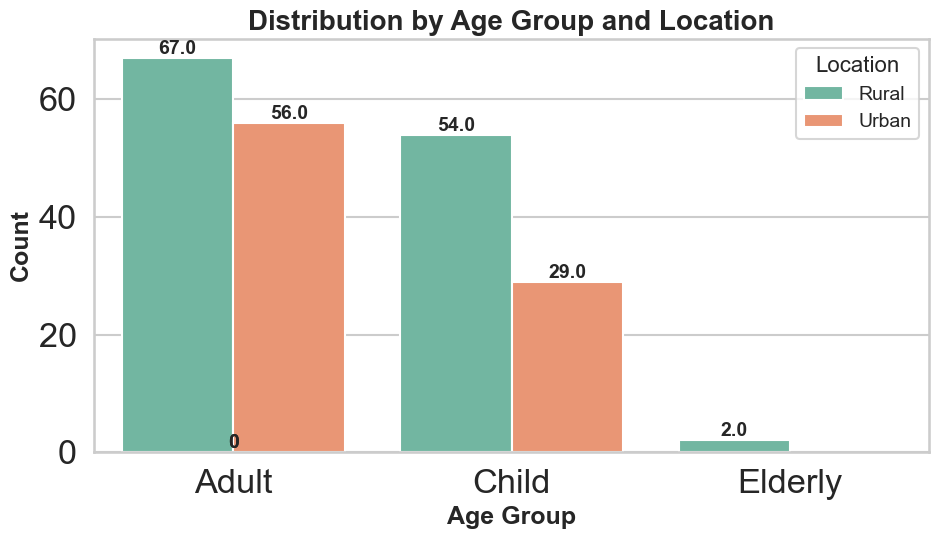

In [23]:
# Count values
# Set a Seaborn style suitable for presentations
sns.set(style="whitegrid")  # clean background
sns.set_context("talk", font_scale=1.5)  # bigger fonts for posters

# Countplot
plt.figure(figsize=(10,6))
ax = sns.countplot(
    data=metadata, 
    x='age', 
    hue='Lifestyle', 
    palette='Set2',  # soft, clear colors
    order=metadata['age'].value_counts().index  # order bars by frequency
)

# Add counts above bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=14, fontweight='bold')

# Labels and title
plt.xlabel('Age Group', fontsize=18, fontweight='bold')
plt.ylabel('Count', fontsize=18, fontweight='bold')
plt.title('Distribution by Age Group and Location', fontsize=20, fontweight='bold')
# plt.ylim(0, 75)

# Adjust legend
plt.legend(title='Location', title_fontsize=16, fontsize=14)

plt.tight_layout()
plt.show()

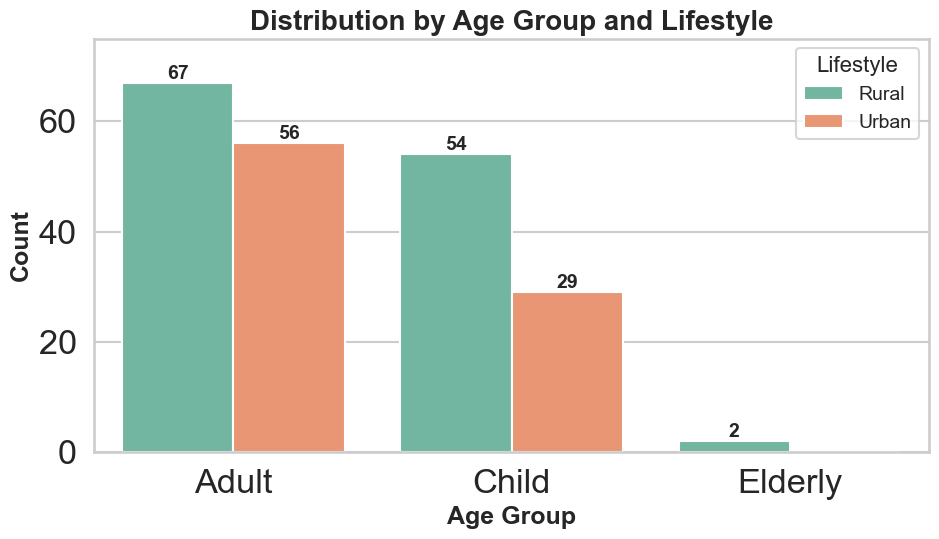

In [24]:
from itertools import product
# Ensure all combinations of age × Lifestyle exist
age_groups = metadata['age'].unique()
lifestyles = metadata['Lifestyle'].unique()
all_combinations = pd.DataFrame(list(product(age_groups, lifestyles)), columns=['age', 'Lifestyle'])

# Count actual occurrences
metadata_counts = metadata.groupby(['age','Lifestyle']).size().reset_index(name='count')

# Merge to include missing combinations and fill with 0
metadata_complete = all_combinations.merge(metadata_counts, on=['age','Lifestyle'], how='left').fillna(0)

# Set a Seaborn style suitable for posters
sns.set(style="whitegrid")
sns.set_context("talk", font_scale=1.5)

# Plot
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=metadata_complete,
    x='age',
    y='count',
    hue='Lifestyle',
    palette='Set2',
    order=sorted(age_groups)  # ensures consistent order
)

# Add counts above bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # only annotate non-zero bars
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Labels and title
plt.xlabel('Age Group', fontsize=18, fontweight='bold')
plt.ylabel('Count', fontsize=18, fontweight='bold')
plt.title('Distribution by Age Group and Lifestyle', fontsize=20, fontweight='bold')
plt.ylim(0, 75)
# Legend styling
plt.legend(title='Lifestyle', title_fontsize=16, fontsize=14)
plt.savefig('EDA.png', dpi = 400, bbox_inches='tight')
plt.tight_layout()
plt.show()

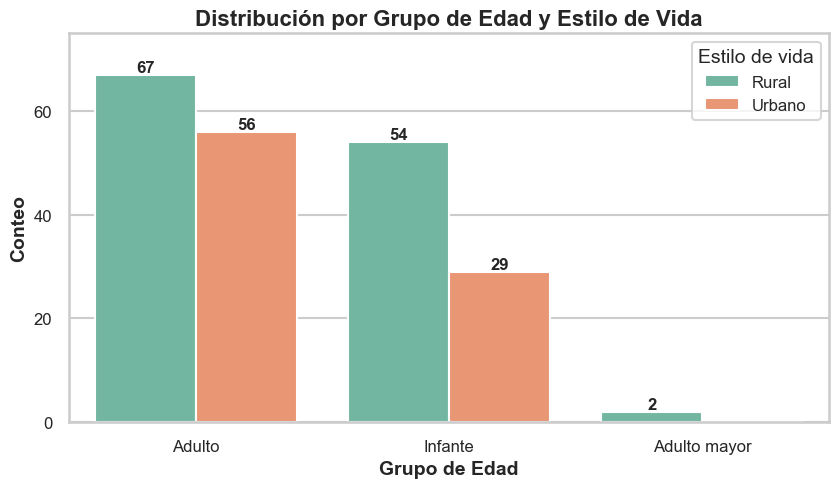

In [34]:
from itertools import product
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- INICIO: Traducción de los valores de las columnas a español ---
# Nota: Esto asume que el DataFrame original 'metadata' tiene los valores en inglés
# ('Urban', 'Adult', 'Child', 'Elderly').

# 1. Traducción de la columna 'Lifestyle' (Leyenda)
metadata['Lifestyle_spa'] = metadata['Lifestyle'].replace({
    'Urban': 'Urbano',
    'Rural': 'Rural' # 'Rural' se mantiene igual en español
})

# 2. Traducción de la columna 'age' (Eje X)
metadata['age_spa'] = metadata['age'].replace({
    'Adult': 'Adulto',
    'Child': 'Infante',
    'Elderly': 'Adulto mayor',
})
# --- FIN: Traducción de los valores de las columnas a español ---


# Definir el orden deseado de los grupos de edad en español para el eje X
age_order_spanish = ['Adulto', 'Infante', 'Adulto mayor']

# Asegurar que todas las combinaciones de edad × Estilo de Vida existan
age_groups = metadata['age_spa'].unique()
lifestyles = metadata['Lifestyle_spa'].unique()
all_combinations = pd.DataFrame(list(product(age_groups, lifestyles)), columns=['age_spa', 'Lifestyle_spa'])

# Contar las ocurrencias reales
metadata_counts = metadata.groupby(['age_spa','Lifestyle_spa']).size().reset_index(name='count')

# Fusionar para incluir combinaciones faltantes y llenar con 0
metadata_complete = all_combinations.merge(metadata_counts, on=['age_spa','Lifestyle_spa'], how='left').fillna(0)

# Establecer un estilo Seaborn adecuado para carteles
sns.set(style="whitegrid")
sns.set_context("talk", font_scale=1.5)

# Trazar el gráfico
plt.figure(figsize=(9,5.5))
ax = sns.barplot(
    data=metadata_complete,
    x='age_spa',
    y='count',
    hue='Lifestyle_spa',
    palette='Set2',
    order=age_order_spanish # Usar el orden definido en español para el eje X
)

# Añadir conteos encima de las barras
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # solo anotar barras distintas de cero
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

# Etiquetas y título (¡en español!)
plt.xlabel('Grupo de Edad', fontsize=14, fontweight='bold')
plt.ylabel('Conteo', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)   # X-axis tick labels (Adulto, Infante, etc.)
plt.yticks(fontsize=12)
plt.title('Distribución por Grupo de Edad y Estilo de Vida', fontsize=16, fontweight='bold')
plt.ylim(0, 75)
# Estilo de la leyenda (¡en español!)
# El título ya está en español, y las etiquetas de la leyenda son los valores traducidos de 'Lifestyle'.
plt.legend(title='Estilo de vida', title_fontsize=14, fontsize=12)
plt.savefig('EDA_spa.png', dpi = 500, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
from itertools import product
# Ensure all combinations of age × Lifestyle exist
age_groups = metadata['age'].unique()
lifestyles = metadata['Lifestyle'].unique()
all_combinations = pd.DataFrame(list(product(age_groups, lifestyles)), columns=['age', 'Lifestyle'])

# Count actual occurrences
metadata_counts = metadata.groupby(['age','Lifestyle']).size().reset_index(name='count')

# Merge to include missing combinations and fill with 0
metadata_complete = all_combinations.merge(metadata_counts, on=['age','Lifestyle'], how='left').fillna(0)

# Set a Seaborn style suitable for posters
sns.set(style="whitegrid")
sns.set_context("talk", font_scale=1.5)

# Plot
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=metadata_complete,
    x='age',
    y='count',
    hue='Lifestyle',
    palette='Set2',
    order=sorted(age_groups)  # ensures consistent order
)

# Add counts above bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # only annotate non-zero bars
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Labels and title
plt.xlabel('Age Group', fontsize=18, fontweight='bold')
plt.ylabel('Count', fontsize=18, fontweight='bold')
plt.title('Distribution by Age Group and Lifestyle', fontsize=20, fontweight='bold')
plt.ylim(0, 75)
# Legend styling
plt.legend(title='Lifestyle', title_fontsize=16, fontsize=14)
plt.savefig('EDA.png', dpi = 400, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [14]:
metadata['age'].value_counts()

age
Adult      123
Child       83
Elderly      2
Name: count, dtype: int64

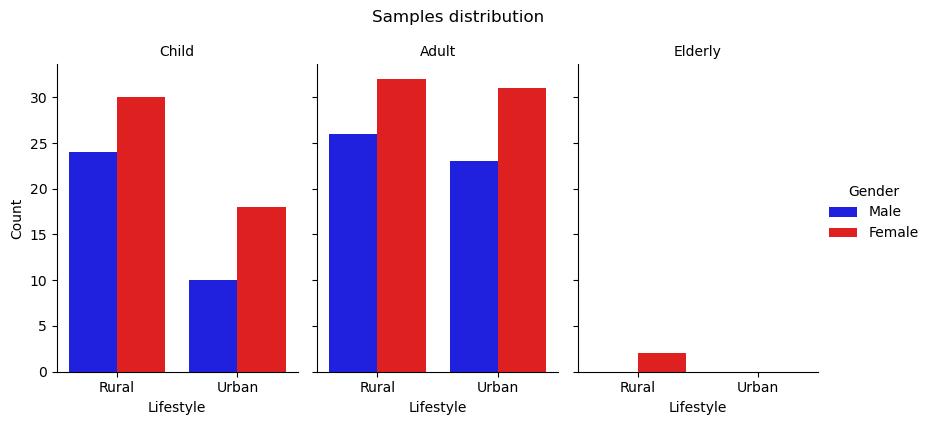

In [9]:
custom_palette = {'Male': 'blue', 'Female': 'red'}  
g = sns.catplot(x='Lifestyle', hue='Gender', col='age', 
                data=metadata, kind='count', height=4, aspect=0.7, palette=custom_palette)
g.set_axis_labels('Lifestyle', 'Count')
g.set_titles('{col_name}')
g.fig.suptitle('Samples distribution', y=1.05)
# plt.savefig('../imgs/samples_distribution.png', dpi = 500)
plt.show()


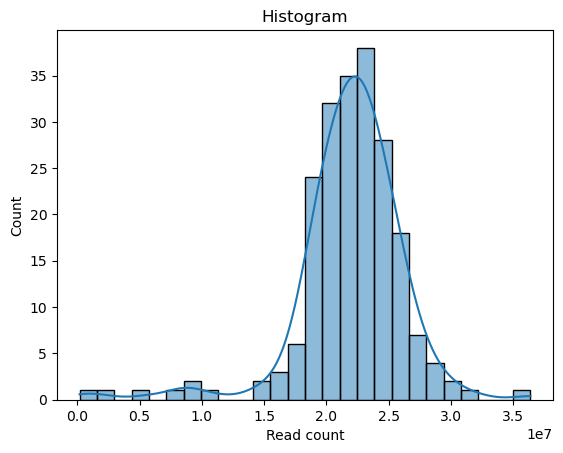

In [11]:
sns.histplot(metadata['Read count'], kde=True)
plt.xlabel('Read count')
plt.ylabel('Count')
plt.title('Histogram')
# plt.savefig('../imgs/reads_histogram.png', dpi = 500)
plt.show()

In [20]:
metadata.sort_values('Read count').head(2)

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent
24,37082_3_16,37082_3#16,GI1_LA9438085,B21,B9/17,185470,37082_3_16,Latinbiota,Healthy,NaN,22.5,NaN,31.0,Adult,Female,Rural,Mexico,North America
37,37082_2_4,37082_2#4,GI1_LA9438025,C42,C41,1779530,37082_2_4,Latinbiota,Healthy,NaN,17.8,NaN,8.0,Child,Male,Urban,Mexico,North America


In [13]:
Q1 = metadata['Read count'].quantile(0.25)
Q3 = metadata['Read count'].quantile(0.75)

In [14]:
IQR = Q3 - Q1

# Step 3: Define the outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [15]:
outliers = metadata[(metadata['Read count'] < lower_bound) | (metadata['Read count'] > upper_bound)]

In [16]:
outliers

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent
5,37082_3_4,37082_3#4,GI1_LA9438070,159,130,31944470,37082_3_4,Latinbiota,Healthy,NaN,22.4,NaN,35.0,Adult,Female,Rural,Mexico,North America
24,37082_3_16,37082_3#16,GI1_LA9438085,B21,B9/17,185470,37082_3_16,Latinbiota,Healthy,NaN,22.5,NaN,31.0,Adult,Female,Rural,Mexico,North America
29,37082_3_11,37082_3#11,GI1_LA9438079,62,51,5669548,37082_3_11,Latinbiota,Healthy,NaN,28.0,NaN,34.0,Adult,Female,Rural,Mexico,North America
33,37082_2_8,37082_2#8,GI1_LA9438033,C50,C49,36372476,37082_2_8,Latinbiota,Healthy,NaN,NaN,NaN,33.0,Adult,Male,Urban,Mexico,North America
36,37082_2_5,37082_2#5,GI1_LA9438026,C43,C42,8556292,37082_2_5,Latinbiota,Healthy,NaN,NaN,NaN,NaN,NaN,Female,Urban,Mexico,North America
37,37082_2_4,37082_2#4,GI1_LA9438025,C42,C41,1779530,37082_2_4,Latinbiota,Healthy,NaN,17.8,NaN,8.0,Child,Male,Urban,Mexico,North America
97,37035_7_23,37035_7#23,GI1_LA9825342,114,114,8502694,37035_7_23,Latinbiota,Healthy,NaN,NaN,NaN,NaN,NaN,NaN,Rural,Mexico,North America
150,37035_1_4,37035_1#4,GI1_LA9438113,125,135,11001358,37035_1_4,Latinbiota,Healthy,NaN,14.9,NaN,9.0,Child,Female,Rural,Mexico,North America
179,36703_3_6,36703_3#6,GI1_LA9438031,C48,C47,8934960,36703_3_6,Latinbiota,Healthy,NaN,NaN,NaN,4.0,Child,Male,Urban,Mexico,North America


In [35]:
rare = ['37082_3#16',
'37082_2#4',
'37035_2#22',
'37035_7#18',
'36703_3#20',
'36703_3#4']


In [36]:
metadata[metadata['Lane'].isin(rare)][['Lane', 'Read count', 'BMI', 'Age', 'Age group', 'Gender', 'Lifestyle']]

,Lane,Read count,BMI,Age,Age group,Gender,Lifestyle
24,37082_3#16,185470,22.5,31.0,Adult,Female,Rural
37,37082_2#4,1779530,17.8,8.0,Child,Male,Urban
103,37035_7#18,22573852,NaN,NaN,NaN,NaN,Rural
130,37035_2#22,24769900,NaN,8.0,Child,Male,Urban
181,36703_3#4,20667418,NaN,NaN,NaN,NaN,Urban
195,36703_3#20,16695310,14.6,7.0,Child,Female,Rural


In [39]:
data_ext = pd.read_excel('../datasets/combinado_revisado_final.xlsx')

In [41]:
data_ext[data_ext['Lane'].isin(rare)].to_csv('raros_ext.csv')